In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_and_plot(filename):
    # 1. Считываем метаданные (размеры I и J)
    with open(filename, 'r') as f:
        content = f.read()
    
    # Ищем значения I и J в заголовке с помощью регулярных выражений
    # Формат: ZONE I = 128, J = 64 ...
    i_match = re.search(r'I\s*=\s*(\d+)', content)
    j_match = re.search(r'J\s*=\s*(\d+)', content)
    
    if not i_match or not j_match:
        print("Ошибка: Не удалось найти размеры I и J в заголовке файла.")
        return

    nx = int(i_match.group(1)) # I (количество точек по X)
    ny = int(j_match.group(1)) # J (количество точек по Y)
    
    print(f"Размер сетки найден: {nx} x {ny} (Всего точек: {nx*ny})")

    # 2. Считываем числовые данные
    # Пропускаем первые 3 строки заголовка (TITLE, VARIABLES, ZONE)
    # Если заголовок больше, skiprows нужно увеличить или определять динамически
    try:
        data = np.loadtxt(filename, skiprows=3)
    except Exception as e:
        print(f"Ошибка при чтении данных: {e}")
        return

    # Проверка целостности данных
    if data.shape[0] != nx * ny:
        print(f"Внимание: Ожидалось {nx*ny} строк данных, но найдено {data.shape[0]}.")
        # Попытка продолжить, если данных меньше (обрезать) или больше
        min_len = min(data.shape[0], nx * ny)
        data = data[:min_len]

    # 3. Подготовка данных
    # В файле столбцы: 0 -> X, 1 -> Y, 2 -> Height
    # Формат DATAPACKING=POINT обычно идет построчно (сначала меняется X, потом Y)
    
    # Извлекаем столбцы
    x_flat = data[:, 0]
    y_flat = data[:, 1]
    z_flat = data[:, 2] # Высота

    # Преобразуем плоские массивы в 2D сетки (reshape)
    # Порядок 'C' (row-major) означает, что заполняем построчно (сначала X пробегает I значений)
    X = x_flat.reshape(ny, nx)
    Y = y_flat.reshape(ny, nx)
    Z = z_flat.reshape(ny, nx)

    # 4. Построение графика
    plt.figure(figsize=(10, 6))
    
    # Вариант А: Контурная заливка (мягкие переходы, как на топографических картах)
    # levels=20 - количество уровней цветов
    # cmap='terrain' или 'viridis', 'jet', 'plasma' - цветовые схемы
    contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
    
    # Добавляем цветовую шкалу (легенду высот)
    cbar = plt.colorbar(contour)
    cbar.set_label('Height', rotation=270, labelpad=15)

    # Настройки осей и заголовка
    plt.title('Карта высот (Вид сверху)')
    plt.xlabel('X')
    plt.ylabel('Y')
    
    # Сохраняем пропорции осей, чтобы карта не искажалась
    plt.axis('equal') 
    
    plt.tight_layout()
    plt.show()

# --- ЗАПУСК ---
# Укажите имя вашего файла здесь
file_path = 'data.plt' 

# Если у вас нет файла и вы хотите протестировать код прямо сейчас,
# раскомментируйте блок ниже для создания тестового файла:
"""
with open(file_path, 'w') as f:
    f.write('TITLE = "nse-3D [F(X,Y)]"\n')
    f.write('VARIABLES = "X", "Y", "height"\n')
    f.write('ZONE I = 5, J = 4, DATAPACKING = POINT, SOLUTIONTIME = 0.000000\n')
    # Генерируем тестовые данные 5x4
    for y in range(4):
        for x in range(5):
            f.write(f"{x*1.0} {y*1.0} {(x*y)}\n")
"""


'\nwith open(file_path, \'w\') as f:\n    f.write(\'TITLE = "nse-3D [F(X,Y)]"\n\')\n    f.write(\'VARIABLES = "X", "Y", "height"\n\')\n    f.write(\'ZONE I = 5, J = 4, DATAPACKING = POINT, SOLUTIONTIME = 0.000000\n\')\n    # Генерируем тестовые данные 5x4\n    for y in range(4):\n        for x in range(5):\n            f.write(f"{x*1.0} {y*1.0} {(x*y)}\n")\n'

Размер сетки найден: 128 x 64 (Всего точек: 8192)


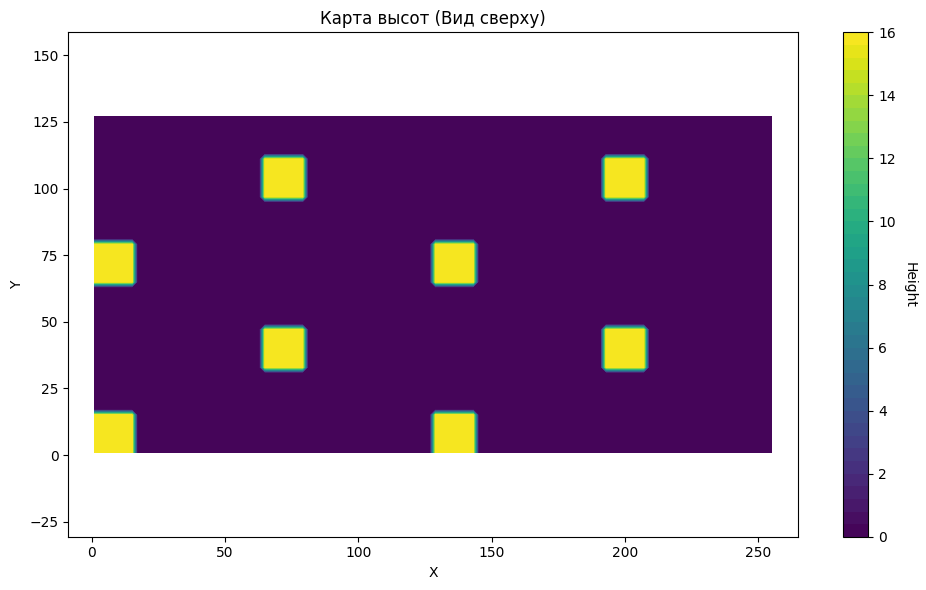

In [3]:
parse_and_plot('./topography-.plt')
